In [45]:
from functions import *
import matplotlib.pyplot as plt
import corner
import matplotlib.gridspec as gridspec
import h5py
import matplotlib
%matplotlib widget

def get_QLF(z, dM, bin_num = 100, sig_lnMstar = 0.7, sig_lnX = [3.5,2.2]):

    qlf = QLF(z, bin_num)
    qlf.get_dNdlnMstar(sig_lnMstar)
    qlf.get_SMBM(dM)
    qlf.get_dNdlnL(sig_lnX)
    
    return qlf.LumBins, np.log10(qlf.dNdlnL * np.log(10))

qlf = QLF(2, 100)
qlf.get_dNdlnMstar(.7)
qlf.get_SMBM(0.4)
%timeit qlf.get_dNdlnL([6,2])

3.39 ms ± 123 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Luminosity vs. Obscuration fraction plot.

In [571]:
qlf = QLF(2, 500)
LumBins = qlf.LumBins

Rl = 0.8
Rh = 0.2
Lc = 10**43.7
Lx = 0.037*10**(LumBins + np.log10(3.9e33))
FOb = Rl * np.e**(-(Lx/Lc)) + Rh * (1 - np.e**(-Lx/Lc))

gs = gridspec.GridSpec(1, 2)
fig = plt.figure(figsize=(12,6))
ls = 12
ts = 16

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey = ax0)
ax0.plot(Lx, FOb, c='k')
ax1.plot(10**LumBins, FOb, c='k')

ax0.set_ylabel('Absorption/Obscuration Fraction', fontsize = ls)
ax0.set_xlabel(r'L$_{\rm{X}}$ erg/s', fontsize = ls)
ax0.set_xscale('log')

ax1.set_xlabel(r'log$_{10}$[L$_{\rm{bol}}$/L$_{\odot}]$', fontsize = ls)
ax1.text(10e7, .4, r'L$_{\rm{X}} = 0.037$ L$_{\rm{bol}}$', fontsize = ls)
ax1.set_xscale('log')
plt.setp(ax1.get_yticklabels(), visible=False)

plt.suptitle('Absorption/Obscuration Fraction vs. Luminosity', fontsize = ts)
gs.tight_layout(fig, rect=[0, 0, 1, 0.97])

FigureCanvasNbAgg()

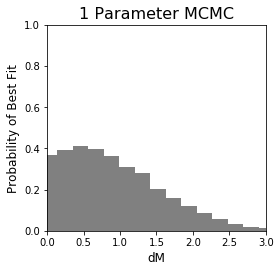

In [49]:
npoints = 20000
nbin = 40
dM = np.random.randn(npoints) + 0.4
Xsig1 = [np.random.uniform(low = 0, high = 10) for i in range(npoints)]
Xsig2 = np.random.randn(npoints) + 2.7

fig = plt.figure(figsize=(4,4))

ls = 12
ts = 16

plt.hist(dM, bins = nbin, color='gray', density=True)
plt.xlabel('dM', fontsize = ls)
plt.ylabel('Probability of Best Fit', fontsize = ls)
plt.title('1 Parameter MCMC', fontsize = ts)
plt.axis([0,3,0,1])
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig('test.pdf')

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "


Text(0.5,0.98,'2-Parameter Fit Distribution Plot')

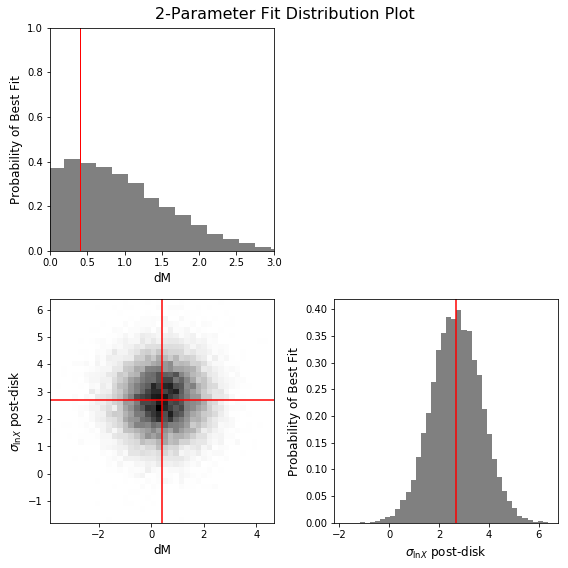

In [55]:
npoints = 20000
nbin = 40
dM = np.random.randn(npoints) + 0.4
Xsig1 = [np.random.uniform(low = 0, high = 10) for i in range(npoints)]
Xsig2 = np.random.randn(npoints) + 2.7

gs = gridspec.GridSpec(2, 2)
fig = plt.figure(figsize=(8,8))

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])

ls = 12
ts = 16

ax0.hist(dM, bins = nbin, color = 'gray', normed=True)
ax1.hist2d(dM, Xsig2, bins = nbin, cmap = 'binary', normed=True)
ax2.hist(Xsig2, bins = nbin, color = 'gray', normed=True)
ax0.axis([0,3,0,1])

ax0.set_xlabel('dM', fontsize = ls)
ax0.set_ylabel('Probability of Best Fit', fontsize = ls)
ax0.axvline(np.median(dM), color='r', lw=1)

ax1.set_xlabel('dM', fontsize = ls)
ax1.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk', fontsize = ls)
ax1.axvline(np.median(dM), color='r')
ax1.axhline(np.median(Xsig2), color='r')

ax2.set_xlabel(r'$\sigma_{\ln{X}}$ post-disk', fontsize = ls)
ax2.set_ylabel('Probability of Best Fit', fontsize = ls)
ax2.axvline(np.median(Xsig2), color='r')

gs.tight_layout(fig, rect=[0, 0, 1, 0.97])
plt.suptitle('2-Parameter Fit Distribution Plot', fontsize = ts)

Text(0.5,0.98,'3-Parameter Fit Distribution Plot')

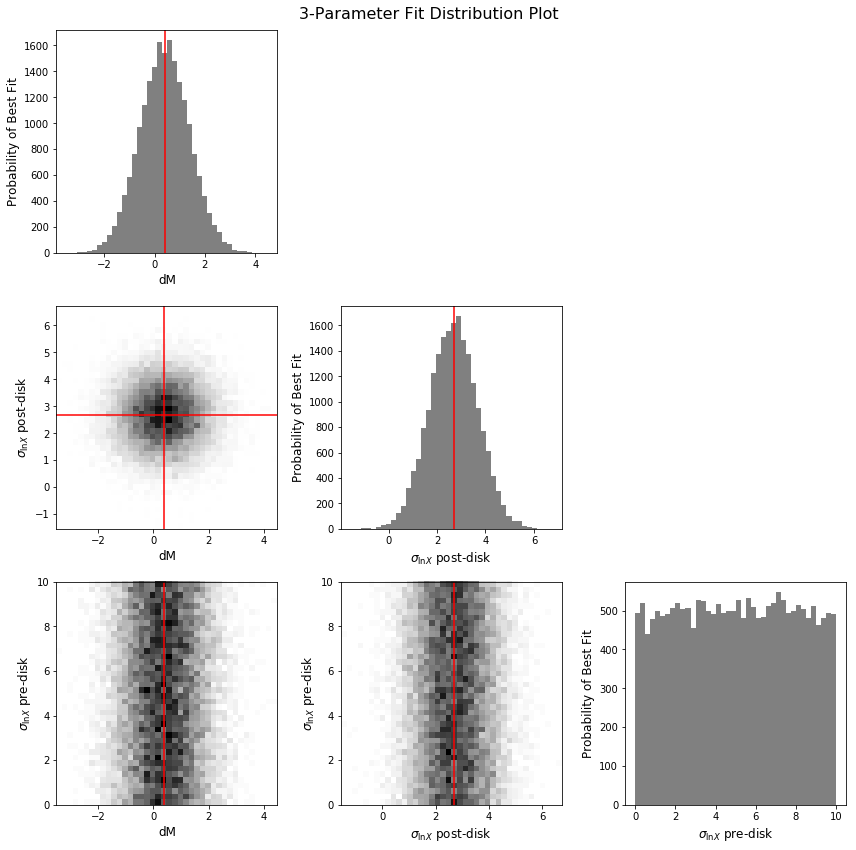

In [76]:
npoints = 20000
nbin = 40
dM = np.random.randn(npoints) + 0.4
Xsig1 = [np.random.uniform(low = 0, high = 10) for i in range(npoints)]
Xsig2 = np.random.randn(npoints) + 2.7

gs = gridspec.GridSpec(3, 3)
fig = plt.figure(figsize=(12,12))

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])
ax3 = fig.add_subplot(gs[2, 0])
ax4 = fig.add_subplot(gs[2, 1])
ax5 = fig.add_subplot(gs[2, 2])

ls = 12
ts = 16

ax0.hist(dM, bins = nbin, color = 'gray')
ax1.hist2d(dM, Xsig2, bins = nbin, cmap = 'binary')
ax2.hist(Xsig2, bins = nbin, color = 'gray')
ax3.hist2d(dM, Xsig1, bins = nbin, cmap = 'binary')
ax4.hist2d(Xsig2, Xsig1, bins = nbin, cmap = 'binary')
ax5.hist(Xsig1, bins = nbin, color = 'gray')

ax0.set_xlabel('dM', fontsize = ls)
ax0.set_ylabel('Probability of Best Fit', fontsize = ls)
ax0.axvline(np.median(dM), color='r')

ax1.set_xlabel('dM', fontsize = ls)
ax1.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk', fontsize = ls)
ax1.axvline(np.median(dM), color='r')
ax1.axhline(np.median(Xsig2), color='r')

ax2.set_xlabel(r'$\sigma_{\ln{X}}$ post-disk', fontsize = ls)
ax2.set_ylabel('Probability of Best Fit', fontsize = ls)
ax2.axvline(np.median(Xsig2), color='r')

ax3.set_xlabel('dM', fontsize = ls)
ax3.set_ylabel(r'$\sigma_{\ln{X}}$ pre-disk', fontsize = ls)
ax3.axvline(np.median(dM), color='r')

ax4.set_xlabel(r'$\sigma_{\ln{X}}$ post-disk', fontsize = ls)
ax4.set_ylabel(r'$\sigma_{\ln{X}}$ pre-disk', fontsize = ls)
ax4.axvline(np.median(Xsig2), color='r')

ax5.set_xlabel(r'$\sigma_{\ln{X}}$ pre-disk', fontsize = ls)
ax5.set_ylabel('Probability of Best Fit', fontsize = ls)

gs.tight_layout(fig, rect=[0, 0, 1, 0.97])
plt.suptitle('3-Parameter Fit Distribution Plot', fontsize = ts)

In [48]:
zlist = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
obs_dict = {}
for z in zlist:
    x, y, yerr = grab_obs(z)
    obs_dict[z] = {'# of data points' : len(x), 'median L_bol/L_sol' : np.median(x), 'average uncertainty (sigma)' : np.mean(yerr)}
for i in obs_dict:
    print('Redshift =', i)
    for j in obs_dict[i]:
        print(j, '=', obs_dict[i][j])
    print('\n')

Redshift = 0.0
# of data points = 73
median L_bol/L_sol = 11.4065
average uncertainty (sigma) = 0.2450191780821918


Redshift = 0.1
# of data points = 77
median L_bol/L_sol = 11.3723
average uncertainty (sigma) = 0.24462857142857145


Redshift = 0.2
# of data points = 50
median L_bol/L_sol = 11.79965
average uncertainty (sigma) = 0.27722


Redshift = 0.5
# of data points = 68
median L_bol/L_sol = 12.181149999999999
average uncertainty (sigma) = 0.16729852941176468


Redshift = 1.0
# of data points = 73
median L_bol/L_sol = 12.5267
average uncertainty (sigma) = 0.16296301369863014


Redshift = 1.5
# of data points = 90
median L_bol/L_sol = 12.87335
average uncertainty (sigma) = 0.20214555555555558


Redshift = 2.0
# of data points = 71
median L_bol/L_sol = 13.0795
average uncertainty (sigma) = 0.21146338028169012


Redshift = 2.5
# of data points = 50
median L_bol/L_sol = 13.237400000000001
average uncertainty (sigma) = 0.256196


Redshift = 3.0
# of data points = 57
median L_bol/L_sol 

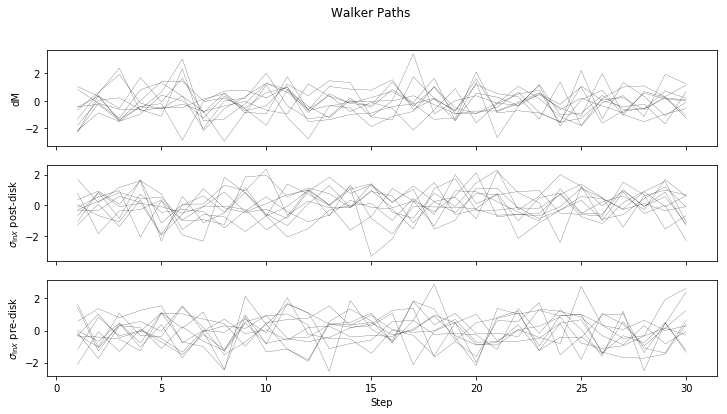

In [88]:
gs = gridspec.GridSpec(3, 1)
fig = plt.figure(figsize=(12,6))

ax2 = fig.add_subplot(gs[2, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex = ax2)
ax0 = fig.add_subplot(gs[0, 0], sharex = ax2)
plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax0.get_xticklabels(), visible=False)
ax0.set_ylabel('dM')
ax1.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk')
ax2.set_ylabel(r'$\sigma_{\ln{X}}$ pre-disk')
ax2.set_xlabel('Step')
plt.suptitle('Walker Paths')

w1 = np.random.randn(300)
w2 = np.random.randn(300)
w3 = np.random.randn(300)
walkerid = np.zeros(300)
count = 0
for i in range(1,11):
    walkerid[0+count:30+count] = i
    count += 30

stepnum = int(len(w1)/len(set(walkerid)))
steps = np.linspace(1,stepnum,stepnum)
for i in set(walkerid):
    ax0.plot(steps, w1[walkerid == i], c='k', lw=0.2)
    ax1.plot(steps, w2[walkerid == i], c='k', lw=0.2)
    ax2.plot(steps, w3[walkerid == i], c='k', lw=0.2)
    

    

In [10]:
plt.close('all')
sigpre = 3.5
sigpost = 2.5
dM1 = 0.3
dM2 = 3.0

zlist = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]

fig = plt.figure(figsize=(26,12))
gs = gridspec.GridSpec(3, 5)
count = 0
for z, i, j in zip(zlist,[0,0,0,0,0,1,1,1,1,1,2,2,2,2,2],[0,1,2,3,4,0,1,2,3,4,0,1,2,3,4]):

    xt, yt , yerr = np.array(grab_obs(z))   
    ax = fig.add_subplot(gs[i, j])
    xm, ym = get_QLF(z = z, dM = dM1, bin_num=200, sig_lnX = [sigpre,sigpost], sig_lnMstar = .7)
    ax.plot(xm,ym,color='b')
    xm, ym = get_QLF(z = z, dM = dM2, bin_num=200, sig_lnX = [sigpre,sigpost], sig_lnMstar = .7)
    ax.plot(xm,ym,color='r')
    if count == 1:
        ax.text(11.5,-2.5,'dM = '+str(dM1),color='b')
        ax.text(13.5, -2.5, 'dM = '+str(dM2), color='r')
        ax.text(12, -3.5, r'$\sigma_{\ln{X}}$ post-disk = '+str(sigpre), color = 'k')
        ax.text(12, -4.5, r'$\sigma_{\ln{X}}$ pre-disk = '+str(sigpost), color = 'k')
    
    ax.axis([6,16,-12,0])
    ax.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$')
    ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$')
    ax.text(10,-8,'z = '+str(z), fontsize=12)
    ax.errorbar(xt, yt, yerr = yerr, fmt = 'o', markersize = .5,color='gray')
    count+=1
        
plt.tight_layout()
plt.savefig('plots/QLFvsObs_MCMC_allz.pdf')

FigureCanvasNbAgg()

In [584]:
z = 2
bins = 100
siglnX1 = 6.0 
xa, ya, yerr = grab_obs(z)
num_obs = len(xa)

def get_QLF(z, dM, bin_num = 300, sig_lnMstar = 0.7, sig_lnX = [3.5,2.2]):

    qlf = QLF(z, bin_num)
    qlf.LumBins = np.linspace(8.5, 16.5, bin_num)
    qlf.get_dNdlnMstar(sig_lnMstar)
    qlf.get_SMBM(dM)
    qlf.get_dNdlnL(sig_lnX)
    
    return qlf.LumBins, np.log10(qlf.dNdlnL * np.log(10))

def calc_chi2(ym, ya, yerr):
    return np.sum(((ym-ya)/yerr)**2)

def get_mdat(xsig2, dm, z, xa):
    sigs = [siglnX1,xsig2[0]]
    if dm < 0.75:
        xm, ym = get_QLF(z, dM = dm, sig_lnX = sigs, bin_num =1200)
    else:
        xm, ym = get_QLF(z, dM = dm, sig_lnX = sigs)
    ymi = np.interp(xa, xm, ym)
    return ymi

def get_chi2(dm, xsig2, z):
    ymi = get_mdat(xsig2, dm, z, xa)
    chi2 = calc_chi2(np.array(ymi), np.array(ya), np.array(yerr))
    return chi2
    
siglnX2 = np.linspace(8.,1., bins)
dM = np.linspace(0,3.,bins)
dM[0] = 0.01
extent = [dM[0], dM[-1], siglnX2[-1], siglnX2[0]]
yax = siglnX2.reshape((bins,1))
xax = dM.reshape((bins, 1))

def get_gridline(yax, z):
    gridline = np.apply_along_axis(get_chi2, 1, xax, yax, z)
    return gridline

grid2d = np.apply_along_axis(get_gridline, 1, yax, z)

maxl = []
for n in grid2d:
    maxl.append(max(n))
    
minl = []
for m in grid2d:
    minl.append(min(m))

f = h5py.File("test.h5py", "w")

f.attrs.modify('bins', bins)
f.attrs.modify('siglnX1', siglnX1)
f.attrs.modify('x-axis', 'dM')
f.attrs.modify('y-axis', 'siglnX2')
dset = f.create_dataset('dM', data = dM)
dset = f.create_dataset('siglnX2', data = siglnX2)
dset = f.create_dataset('extent', data = extent)

grp = f.create_group("z="+str(z))
dset = grp.create_dataset('chi2_grid', data = grid2d)
dset = grp.create_dataset('min-max', data = [min(minl), max(maxl)])
dset = grp.create_dataset('#_observation', data = (num_obs,))

f.close()

In [397]:
z = 2
bins = 50
siglnX1 = 6.0 
xa, ya, yerr = grab_obs(z)
num_obs = len(xa)

def get_QLF(z, dM, bin_num = 300, sig_lnMstar = 0.7, sig_lnX = [3.5,2.2]):

    qlf = QLF(z, bin_num)
    qlf.LumBins = np.linspace(8.5, 16.5, bin_num)
    qlf.get_dNdlnMstar(sig_lnMstar)
    qlf.get_SMBM(dM)
    qlf.get_dNdlnL(sig_lnX)
    
    return qlf.LumBins, np.log10(qlf.dNdlnL * np.log(10))

def calc_like(ym, ya, yerr):
    chi2 = (((ym-ya)/yerr)**2)/(len(ya)-1)
    return np.prod(np.e**(-chi2)/(2*np.pi*yerr))

def get_mdat(xsig2, dm, z, xa):
    sigs = [siglnX1,xsig2[0]]
    xm, ym = get_QLF(z, dM = dm, sig_lnX = sigs)
    ymi = np.interp(xa, xm, ym)
    return ymi

def get_like(dm, xsig2, z):
    ymi = get_mdat(xsig2, dm, z, xa)
    like = calc_like(np.array(ymi), np.array(ya), np.array(yerr))
    return like
    
siglnX2 = np.linspace(8.,1., bins)
dM = np.linspace(0,3.,bins)
dM[0] = 0.01
extent = [dM[0], dM[-1], siglnX2[-1], siglnX2[0]]
yax = siglnX2.reshape((bins,1))
xax = dM.reshape((bins, 1))

def get_gridline(yax, z):
    gridline = np.apply_along_axis(get_like, 1, xax, yax, z)
    return gridline

grid2d = np.apply_along_axis(get_gridline, 1, yax, z)

# maxl = []
# for n in grid2d:
#     maxl.append(max(n))
    
# minl = []
# for m in grid2d:
#     minl.append(min(m))

f = h5py.File("testlike.h5py", "w")

f.attrs.modify('bins', bins)
f.attrs.modify('siglnX1', siglnX1)
f.attrs.modify('x-axis', 'dM')
f.attrs.modify('y-axis', 'siglnX2')
dset = f.create_dataset('dM', data = dM)
dset = f.create_dataset('siglnX2', data = siglnX2)
dset = f.create_dataset('extent', data = extent)

grp = f.create_group("z="+str(z))

# dset = grp.create_dataset('chi2_grid', data = grid2d)
# dset = grp.create_dataset('min-max', data = [min(minl), max(maxl)])

dset = grp.create_dataset('#_observation', data = (num_obs,))
dset = grp.create_dataset('Likelehood_grid', data = grid2d)

f.close()

In [585]:
f = h5py.File("test.h5py", "r")
grid2d = f['/z=2/chi2_grid'][:]
extent = f['extent'][:]
maxval = f['/z=2/min-max'][:][1]
minval = f['/z=2/min-max'][:][0]
numob = f['/z=2/#_observation'][:][0]
f.close()

print(minval/maxval)

ticks = [0.70,0.84,0.90,0.95,0.98,0.99]
ticklabels = [str(i) for i in ticks]
ticklabels[0] = '< '+ticklabels[0]
ticklabels[-1] = '> '+ticklabels[-1]

print(min(dM[1:]))
fig, ax = plt.subplots(figsize=(5.5,4))
img = ax.imshow(np.e**(-grid2d/maxval), cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=5))
ax.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk')
ax.set_xlabel('dM')
ax.axis([0.01,3,1,6])
cbar = plt.colorbar(img, label=r'Likelihood', pad = 0.05, ticks = ticks)
cbar.ax.set_yticklabels(ticklabels)
cont = ax.contour(np.e**(-grid2d/maxval), cmap='binary', extent = extent, origin = 'image', levels=ticks, vmin = 0.5)
cbar = plt.colorbar(cont, label=r'Likelihood', pad = 0.05, ticks = ticks)
plt.tight_layout()


0.008027681667844197
0.030303030303030304


FigureCanvasNbAgg()

In [533]:
plt.close('all')
bins = 20
siglnX1 = 6.0 

def get_QLF(z, dM, bin_num = 300, sig_lnMstar = 0.7, sig_lnX = [3.5,2.2]):

    qlf = QLF(z, bin_num)
    qlf.LumBins = np.linspace(8.5, 16.5, bin_num)
    qlf.get_dNdlnMstar(sig_lnMstar)
    qlf.get_SMBM(dM)
    qlf.get_dNdlnL(sig_lnX)
    
    return qlf.LumBins, np.log10(qlf.dNdlnL * np.log(10))

def calc_chi2(ym, ya, yerr):
    return np.sum(((ym-ya)/yerr)**2)

def get_mdat(xsig2, dm, z, xa):
    sigs = [siglnX1,xsig2[0]]
    xm, ym = get_QLF(z, dM = dm, sig_lnX = sigs)
    ymi = np.interp(xa, xm, ym)
    return ymi

def get_chi2(dm, xsig2, z):
    ymi = get_mdat(xsig2, dm, z, xa)
    chi2 = calc_chi2(np.array(ymi), np.array(ya), np.array(yerr))
    return chi2
    
siglnX2 = np.linspace(8.,1., bins)
dM = np.linspace(0,3.,bins)
dM[0] = 0.01
extent = [dM[0], dM[-1], siglnX2[-1], siglnX2[0]]
yax = siglnX2.reshape((bins,1))
xax = dM.reshape((bins, 1))

def get_gridline(yax, z):
    gridline = np.apply_along_axis(get_chi2, 1, xax, yax, z)
    return gridline


totpoints = 0
fig = plt.figure(figsize=(24,10))
gs = gridspec.GridSpec(3, 7)
stack = np.zeros((bins, bins))
zlist = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
for z, i, j in zip(zlist,[0,0,0,0,0,1,1,1,1,1,2,2,2,2,2],[0,1,2,3,4,0,1,2,3,4,0,1,2,3,4]):
    
    
    xa, ya, yerr = grab_obs(z)
    num_obs = len(xa)
    grid2d = np.apply_along_axis(get_gridline, 1, yax, z)

    ax = fig.add_subplot(gs[i, j])
    maxl = []
    for n in grid2d:
        maxl.append(max(n))
    maxval = max(maxl)
    img = ax.imshow(np.e**(-grid2d/maxval), cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=5), vmin = .36, vmax = 1)
    ax.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk')
    ax.set_xlabel('dM')
    ax.axis([0.01,3,1,6])
    ax.set_title('z = '+str(z))
    plt.contour(np.e**(-grid2d/maxval), cmap='binary', extent = extent, origin = 'image', levels=ticks, vmin = 0.5)
    
    totpoints += len(xobs)
    stack += np.e**(-grid2d/maxval)#*len(xobs)

    

ax1 = fig.add_subplot(gs[1:,5:])

total = ax1.imshow(stack/len(zlist), cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=5), vmin = .36, vmax = 1)
ax1.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk')
ax1.set_xlabel('dM')
ax1.axis([0.01,3,1,6])
ax1.set_title('Stacked z')

ticks = [0.70,0.84,0.90,0.95,0.98,0.99]
ticklabels = [str(i) for i in ticks]
ticklabels[0] = '< '+ticklabels[0]
ticklabels[-1] = '> '+ticklabels[-1]


cbar = plt.colorbar(total, label=r'Likelihood', pad = 0.05, ticks = ticks)
cbar.ax.set_yticklabels(ticklabels)
cont = ax1.contour(stack/len(zlist), cmap='binary', extent = extent, origin = 'image', levels=ticks)
cbar = plt.colorbar(cont, ticks = ticks, orientation='horizontal', label='Contours')

plt.tight_layout()
plt.savefig('test3.pdf')

FigureCanvasNbAgg()

In [555]:
plt.close('all')
bins = 150

ticks = [0.70,0.84,0.90,0.95,0.98,0.99]
ticklabels = [str(i) for i in ticks]
ticklabels[0] = '< '+ticklabels[0]
ticklabels[-1] = '> '+ticklabels[-1]

f = h5py.File("Quest-emcee/chi2_grid_data2.h5py", "r")
extent = f['extent'][:]
f.close()

fig = plt.figure(figsize=(24,10))
gs = gridspec.GridSpec(3, 7)
stack = np.zeros((bins, bins))
zlist = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
for z, i, j in zip(zlist,[0,0,0,0,0,1,1,1,1,1,2,2,2,2,2],[0,1,2,3,4,0,1,2,3,4,0,1,2,3,4]):
    
    
    xa, ya, yerr = grab_obs(z)
    num_obs = len(xa)
    f = h5py.File("Quest-emcee/chi2_grid_data2.h5py", "r")
    grid2d = f['z='+str(z)+'/chi2_grid'][:]
    maxval = f['z='+str(z)+'/min-max'][:][1]
    numob = f['z='+str(z)+'/#_observation'][:][0]
    f.close()

    ax = fig.add_subplot(gs[i, j])
    maxl = []
    for n in grid2d:
        maxl.append(max(n))
    maxval = max(maxl)
    img = ax.imshow(np.e**(-grid2d/maxval), cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=5), vmin = .36, vmax = 1)
    ax.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk')
    ax.set_xlabel('dM')
    ax.axis([0.01,3,1,6])
    ax.set_title('z = '+str(z))
    plt.contour(np.e**(-grid2d/maxval), cmap='binary', extent = extent, origin = 'image', levels=ticks, vmin = 0.5)
    if z == 1.0:
        cont1 = plt.contour(np.e**(-grid2d/maxval), cmap='binary', extent = extent, origin = 'image', levels=ticks, vmin = 0.5)

    
    totpoints += len(xobs)
    stack += np.e**(-grid2d/maxval)#*len(xobs)

    

ax1 = fig.add_subplot(gs[0:2,5:])

total = ax1.imshow(stack/len(zlist), cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=5), vmin = .36, vmax = 1)
ax1.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk')
ax1.set_xlabel('dM')
ax1.axis([0.01,3,1,6])
ax1.set_title('Stacked z')


cbar = plt.colorbar(total, label=r'Likelihood', pad = 0.05, ticks = ticks)
cbar.ax.set_yticklabels(ticklabels)
cont = ax1.contour(stack/len(zlist), cmap='binary', extent = extent, origin = 'image', levels=ticks)
axx = plt.axes([.73, .3, .2, .025],)
cbar = plt.colorbar(cont1, cax = axx, ticks = ticks, orientation='horizontal', label='Contours')

plt.tight_layout()
plt.savefig('plots/chi2_grid.pdf')

FigureCanvasNbAgg()

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/figure.py:2267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


In [43]:
z = 1.5
sigpre = 5.0
sigpost = 2.4
xt, yt , yerr = np.array(grab_obs(z))
fig = plt.figure(figsize=(8,8))
color = ['r','orange','yellow','green','blue','violet','indigo','brown','gray','k']
for dM, c in zip(np.linspace(0.3,3,10), color):
    xm, ym = get_QLF(z = z, dM = dM, bin_num=200, sig_lnX = [sigpre,sigpost])
    plt.plot(xm, ym, label='dM = '+str(dM)[0:3], c = c)
    plt.axis([6,16,-12,0])
    plt.xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$')
    plt.ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$')
    plt.errorbar(xt, yt, yerr = yerr, fmt = 'o', markersize = .5,color='gray')
    plt.text(8, -1, r'$\sigma_{\ln{X}}$ post-disk = '+str(sigpre), color = 'k')
    plt.text(8, -1.5, r'$\sigma_{\ln{X}}$ pre-disk = '+str(sigpost), color = 'k')
    plt.title('z = '+str(z))
plt.legend()
print(np.linspace(0.3,3,10))

FigureCanvasNbAgg()

[0.3 0.6 0.9 1.2 1.5 1.8 2.1 2.4 2.7 3. ]


In [44]:
plt.close('all')
sigpre = 5.0
sigpost = 2.4
color = ['r','orange','yellow','green','blue','violet','indigo','brown','gray','k']

fig = plt.figure(figsize=(30,14))
gs = gridspec.GridSpec(3, 5)

for z, i, j in zip(zlist,[0,0,0,0,0,1,1,1,1,1,2,2,2,2,2],[0,1,2,3,4,0,1,2,3,4,0,1,2,3,4]):
    
    for dM, c in zip(np.linspace(0.3,3,10), color):  
        ax = fig.add_subplot(gs[i, j])
        xm, ym = get_QLF(z = z, dM = dM, bin_num=200, sig_lnX = [sigpre,sigpost])
        ax.plot(xm, ym, color=c, label='dM = '+str(dM)[0:3], lw = 0.75)

    ax.text(9, -7, r'$\sigma_{\ln{X}}$ post-disk = '+str(sigpre), color = 'k')
    ax.text(9, -8, r'$\sigma_{\ln{X}}$ pre-disk = '+str(sigpost), color = 'k')
    ax.axis([6,16,-12,-2])
    ax.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$')
    ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$')
    ax.set_title('z = '+str(z))
    
    xt, yt , yerr = np.array(grab_obs(z)) 
        
    ax.errorbar(xt, yt, yerr = yerr, fmt = 'o', markersize = .5,color='gray', label='Observed')
    ax.legend()
plt.tight_layout()
plt.savefig('plots/varrydM_QLFvsObs_MCMC_allz.pdf')

FigureCanvasNbAgg()

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/cbook/deprecation.py:107: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  warnings.warn(message, mplDeprecation, stacklevel=1)


In [253]:
import itertools

li = np.array(['dM_1','dM_2','dM_3'])
lj = np.array(['post_1','post_2','post_3'])
lk = np.array(['pre_1','pre_2','pre_3'])

combs = np.array(list(itertools.product(li, lj, lk)))

combma = np.reshape(combs,(3,3,3,3))

# print(combma)
# print('break')
# print(combma[0,:,:])
# print(combma[1,:,:]) ###first axis is dM in increasing order
# print('break') 
# print(combma[:,0,:])
# print(combma[:,1,:]) ###second axis is post sig in inccreasing order
# print('break')
# print(combma[:,:,0])
# print(combma[:,:,1]) ###third axis is pre sig in increasing order

def combine(a):
    return a[0]+' '+a[1]+' '+a[2]
new = np.apply_along_axis(combine, 1, combs)
print(new.reshape(3,3,3)[0,:,:])

[['dM_1 post_1 pre_1' 'dM_1 post_1 pre_2' 'dM_1 post_1 pre_3']
 ['dM_1 post_2 pre_1' 'dM_1 post_2 pre_2' 'dM_1 post_2 pre_3']
 ['dM_1 post_3 pre_1' 'dM_1 post_3 pre_2' 'dM_1 post_3 pre_3']]


So doing it like this:

axis1 = dM

axis2 = post_sig

axis3 = pre_sig

sum over axis1 to get post vs pre sig:

    post is on y-axis with increasing order down
    pre is on x-axis with increasing order right
    
sum over axis2 to get dM vs pre:

    dM is on y-axis with increasing order down
    pre is on x-axis with increasing order right
    
sum over axis3 to get dM vs post:

    dM is on y-axis with increasing order down
    post is on x-axis with increasing order right

In [229]:
bins = 30
qlf_bins = 300
sig_lnMstar = 0.7

dM = np.linspace(0.01,3,bins)
xsigpre = np.linspace(1,8,bins)
xsigpost = np.linspace(1,8,bins)

z = 2


qlf = QLF(z, qlf_bins)
qlf.LumBins = np.linspace(8.5, 16.5, qlf_bins)
qlf.get_dNdlnMstar(sig_lnMstar)
xa, ya, yerr = grab_obs(z)
xa = np.array(xa)
ya = np.array(ya)
yerr = np.array(yerr)

def chi2(a):
    dM = a[0]
    sig_lnX = [a[1],a[2]]
    qlf.get_SMBM(dM)
    qlf.get_dNdlnL(sig_lnX)
    xm, ym = qlf.LumBins, np.log10(qlf.dNdlnL * np.log(10))
    ymi = np.interp(xa, xm, ym)
    
    return np.sum(((ymi-ya)/yerr)**2)

combos = np.array(list(itertools.product(dM, xsigpre, xsigpost)))
chi23d = np.apply_along_axis(chi2, 1, combos).reshape(bins, bins, bins)



In [265]:
plt.close('all')
grid2d_dMpost = np.transpose(np.sum(chi23d, axis = 1))


maxl = []
for n in grid2d_dMpost:
    maxl.append(max(n))
maxvalpost = max(maxl)

# extent_dMpost = [xsigpost[0], xsigpost[-1], dM[-1], dM[0]]
extent_dMpost = [dM[0], dM[-1], xsigpost[-1], xsigpost[0]]

ticks = [0.7, 0.8, 0.9, 0.94, 0.97, 0.99]
ticklabels = [str(i) for i in ticks]
ticklabels[0] = '< '+ticklabels[0]
ticklabels[-1] = '> '+ticklabels[-1]
    
img = plt.imshow(np.e**(-grid2d_dMpost/maxvalpost), cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent_dMpost, norm=matplotlib.colors.PowerNorm(gamma=5))
plt.ylabel(r'$\sigma_{\ln{X}}$ post-disk')
plt.xlabel('dM')
plt.colorbar(ticks = ticks, label='Likelihood')
plt.axis([0.01,3,1,8])
plt.title('z = '+str(z))
plt.contour(np.e**(-grid2d_dMpost/maxvalpost), cmap='binary', extent = extent_dMpost, origin = 'image', levels = ticks, vmin = 0.7)
plt.colorbar()
    

FigureCanvasNbAgg()

In [262]:
plt.close('all')
grid2d_dMpre = np.transpose(np.sum(chi23d, axis = 2))


maxl = []
for n in grid2d_dMpre:
    maxl.append(max(n))
maxvalpre = max(maxl)

extent_dMpre = [dM[0], dM[-1], xsigpre[-1], xsigpre[0]]

ticks = [0.52, 0.54, 0.56, 0.58, 0.6, 0.62]
ticklabels = [str(i) for i in ticks]
ticklabels[0] = '< '+ticklabels[0]
ticklabels[-1] = '> '+ticklabels[-1]
    
img = plt.imshow(np.e**(-grid2d_dMpre/maxvalpre), cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent_dMpre, norm=matplotlib.colors.PowerNorm(gamma=5))
plt.ylabel(r'$\sigma_{\ln{X}}$ pre-disk')
plt.xlabel('dM')
plt.colorbar(ticks = ticks, label='Likelihood')
plt.axis([0.01,3,3,8])
plt.title('z = '+str(z))
plt.contour(np.e**(-grid2d_dMpre/maxvalpre), cmap='binary', extent = extent_dMpre, origin = 'image', levels = ticks, vmin = 0.52)
plt.colorbar()
  

FigureCanvasNbAgg()

In [267]:
plt.close('all')
grid2d_postpre = np.transpose(np.sum(chi23d, axis = 0))


maxl = []
for n in grid2d_postpre:
    maxl.append(max(n))
maxvalpostpre = max(maxl)

extent_postpre = [xsigpre[0], xsigpre[-1], xsigpost[-1], xsigpost[0]]

ticks = [0.7, 0.8, 0.9, 0.94, 0.97, 0.99]
ticklabels = [str(i) for i in ticks]
ticklabels[0] = '< '+ticklabels[0]
ticklabels[-1] = '> '+ticklabels[-1]
    
img = plt.imshow(np.e**(-grid2d_postpre/maxvalpostpre), cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent_postpre, norm=matplotlib.colors.PowerNorm(gamma=5))
plt.xlabel(r'$\sigma_{\ln{X}}$ pre-disk')
plt.ylabel(r'$\sigma_{\ln{X}}$ post-disk')
plt.colorbar(ticks = ticks, label='Likelihood')
plt.axis([1,8,3,8])
plt.title('z = '+str(z))
plt.contour(np.e**(-grid2d_postpre/maxvalpostpre), cmap='binary', extent = extent_postpre, origin = 'image', levels = ticks, vmin = 0.7)
plt.colorbar()
  

FigureCanvasNbAgg()

In [306]:
plt.close('all')
dMchi2 = np.sum(chi23d, axis = (2,1))
maxdMlike = max(dMchi2)
postchi2 = np.sum(chi23d, axis = (0,2))
maxpost = max(postchi2)
prechi2 = np.sum(chi23d, axis = (0,1))
maxpre = max(postchi2)
                
dMlike = np.e**(-dMchi2/maxdMlike)
postlike = np.e**(-postchi2/maxpost)
prelike = np.e**(-prechi2/maxpre)
                
fig, ax = plt.subplots()
ax.plot(dM, dMlike, label='dM', c='b')
ax.set_xlabel('dM', color = 'b')
ax.set_ylabel('Likelihood')
axsig = ax.twiny()
axsig.set_xlabel(r'$\sigma_{\ln{X}}$',color='r')
axsig.plot(xsigpre, prelike, c='r', ls = 'dashed', label=r'$\sigma_{\ln{X}}$ pre-disk')
axsig.plot(xsigpost, postlike, c='r', label=r'$\sigma_{\ln{X}}$ post-disk')
fig.legend(loc='upper right', bbox_to_anchor=(0.35,0.3,0.5,0.5))

FigureCanvasNbAgg()